In [1]:
from sklearn.datasets import fetch_openml

# Adult 数据集：预测收入是否 >50K
adult = fetch_openml("adult", version=2, as_frame=True)
X = adult.data      # 特征 DataFrame
y = adult.target    # 标签 Series（字符串：'>50K'、'<=50K'）

print(X.head())
print(X.dtypes)
print(y.value_counts())

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  
0              

In [3]:
import pandas as pd
import numpy as np

# 连续特征：数值型
continuous_features = X.select_dtypes(include=[np.number]).columns.tolist()
# 离散特征：非数值型
discrete_features = [c for c in X.columns if c not in continuous_features]

print("连续特征：", continuous_features)
print("离散特征：", discrete_features)

连续特征： ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
离散特征： ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y, shuffle=True
)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 对离散特征做 One-Hot，连续特征原样传递
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), discrete_features),
        ("num", "passthrough", continuous_features),
    ]
)

X_train_sklearn = preprocess.fit_transform(X_train)
X_test_sklearn = preprocess.transform(X_test)

In [6]:
from decision_tree_ID3 import DecisionTreeContinuous as ID3Tree
from decision_tree_C45 import DecisionTreeC45
from decision_tree_CART import DecisionTreeCART
from sklearn.metrics import accuracy_score, classification_report

In [7]:
id3 = ID3Tree(
    min_samples_split=10,
    continuous_features=continuous_features  # 直接用上面识别好的连续特征名列表
)
id3.fit(X_train, y_train)

id3_train_pred = id3.predict(X_train)
id3_test_pred = id3.predict(X_test)

print("ID3 训练集准确率:", accuracy_score(y_train, id3_train_pred))
print("ID3 测试集准确率:", accuracy_score(y_test, id3_test_pred))

ID3 训练集准确率: 0.9353593260990377
ID3 测试集准确率: 0.8198321162901795


In [8]:
c45 = DecisionTreeC45(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features
)
c45.fit(X_train, y_train)

c45_train_pred = c45.predict(X_train)
c45_test_pred = c45.predict(X_test)

print("C4.5 训练集准确率:", accuracy_score(y_train, c45_train_pred))
print("C4.5 测试集准确率:", accuracy_score(y_test, c45_test_pred))

C4.5 训练集准确率: 0.9059346573459299
C4.5 测试集准确率: 0.8478809800040947


In [9]:
cart = DecisionTreeCART(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features
)
cart.fit(X_train, y_train)

cart_train_pred = cart.predict(X_train)
cart_test_pred = cart.predict(X_test)

print("CART 训练集准确率:", accuracy_score(y_train, cart_train_pred))
print("CART 测试集准确率:", accuracy_score(y_test, cart_test_pred))

CART 训练集准确率: 0.91634736318699
CART 测试集准确率: 0.8354603152937965


In [10]:
from sklearn.tree import DecisionTreeClassifier

# Entropy（类似 ID3/C4.5）
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt_entropy.fit(X_train_sklearn, y_train)

# Gini（类似 CART）
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
dt_gini.fit(X_train_sklearn, y_train)

# 评估
dt_entropy_train_pred = dt_entropy.predict(X_train_sklearn)
dt_entropy_test_pred = dt_entropy.predict(X_test_sklearn)

dt_gini_train_pred = dt_gini.predict(X_train_sklearn)
dt_gini_test_pred = dt_gini.predict(X_test_sklearn)

print("sklearn-Entropy 训练集准确率:", accuracy_score(y_train, dt_entropy_train_pred))
print("sklearn-Entropy 测试集准确率:", accuracy_score(y_test, dt_entropy_test_pred))

print("sklearn-Gini 训练集准确率:", accuracy_score(y_train, dt_gini_train_pred))
print("sklearn-Gini 测试集准确率:", accuracy_score(y_test, dt_gini_test_pred))

sklearn-Entropy 训练集准确率: 0.9999415016525783
sklearn-Entropy 测试集准确率: 0.8184672080802566
sklearn-Gini 训练集准确率: 0.9999415016525783
sklearn-Gini 测试集准确率: 0.8217429877840715


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "algorithm": ["ID3", "C4.5", "CART", "sklearn-Entropy", "sklearn-Gini"],
    "train_accuracy": [
        accuracy_score(y_train, id3_train_pred),
        accuracy_score(y_train, c45_train_pred),
        accuracy_score(y_train, cart_train_pred),
        accuracy_score(y_train, dt_entropy_train_pred),
        accuracy_score(y_train, dt_gini_train_pred),
    ],
    "test_accuracy": [
        accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_test, cart_test_pred),
        accuracy_score(y_test, dt_entropy_test_pred),
        accuracy_score(y_test, dt_gini_test_pred),
    ],
})

print(results)

         algorithm  train_accuracy  test_accuracy
0              ID3        0.935359       0.819832
1             C4.5        0.905935       0.847881
2             CART        0.916347       0.835460
3  sklearn-Entropy        0.999942       0.818467
4     sklearn-Gini        0.999942       0.821743


In [12]:
# 训练带后剪枝的模型
print("="*60)
print("训练后剪枝模型...")
print("="*60)

# ID3 with pruning
id3_pruned = ID3Tree(
    min_samples_split=10,
    continuous_features=continuous_features,
    prune=True,
    validation_split=0.2
)
id3_pruned.fit(X_train, y_train)
id3_pruned_train_pred = id3_pruned.predict(X_train)
id3_pruned_test_pred = id3_pruned.predict(X_test)

print(f"ID3 (剪枝) 训练集准确率: {accuracy_score(y_train, id3_pruned_train_pred):.6f}")
print(f"ID3 (剪枝) 测试集准确率: {accuracy_score(y_test, id3_pruned_test_pred):.6f}")

# C4.5 with pruning
c45_pruned = DecisionTreeC45(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features,
    prune=True,
    validation_split=0.2
)
c45_pruned.fit(X_train, y_train)
c45_pruned_train_pred = c45_pruned.predict(X_train)
c45_pruned_test_pred = c45_pruned.predict(X_test)

print(f"C4.5 (剪枝) 训练集准确率: {accuracy_score(y_train, c45_pruned_train_pred):.6f}")
print(f"C4.5 (剪枝) 测试集准确率: {accuracy_score(y_test, c45_pruned_test_pred):.6f}")

# CART with pruning
cart_pruned = DecisionTreeCART(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features,
    prune=True,
    validation_split=0.2
)
cart_pruned.fit(X_train, y_train)
cart_pruned_train_pred = cart_pruned.predict(X_train)
cart_pruned_test_pred = cart_pruned.predict(X_test)

print(f"CART (剪枝) 训练集准确率: {accuracy_score(y_train, cart_pruned_train_pred):.6f}")
print(f"CART (剪枝) 测试集准确率: {accuracy_score(y_test, cart_pruned_test_pred):.6f}")


训练后剪枝模型...
ID3 (剪枝) 训练集准确率: 0.886893
ID3 (剪枝) 测试集准确率: 0.825292
C4.5 (剪枝) 训练集准确率: 0.883325
C4.5 (剪枝) 测试集准确率: 0.852180
CART (剪枝) 训练集准确率: 0.886893
CART (剪枝) 测试集准确率: 0.846584


In [13]:
# 汇总所有模型结果（包括剪枝前后对比）
all_results = pd.DataFrame({
    "algorithm": [
        "ID3 (raw)", "ID3 (pruning)", 
        "C4.5 (raw)", "C4.5 (pruning)",
        "CART (raw)", "CART (pruning)",
        "sklearn-Entropy", "sklearn-Gini"
    ],
    "train_accuracy": [
        accuracy_score(y_train, id3_train_pred),
        accuracy_score(y_train, id3_pruned_train_pred),
        accuracy_score(y_train, c45_train_pred),
        accuracy_score(y_train, c45_pruned_train_pred),
        accuracy_score(y_train, cart_train_pred),
        accuracy_score(y_train, cart_pruned_train_pred),
        accuracy_score(y_train, dt_entropy_train_pred),
        accuracy_score(y_train, dt_gini_train_pred),
    ],
    "test_accuracy": [
        accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_test, id3_pruned_test_pred),
        accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_test, c45_pruned_test_pred),
        accuracy_score(y_test, cart_test_pred),
        accuracy_score(y_test, cart_pruned_test_pred),
        accuracy_score(y_test, dt_entropy_test_pred),
        accuracy_score(y_test, dt_gini_test_pred),
    ],
})

# 计算过拟合程度
all_results["overfitting"] = all_results["train_accuracy"] - all_results["test_accuracy"]

print("="*80)
print("所有模型性能对比（包括剪枝前后）")
print("="*80)
print(all_results.to_string(index=False))
print("="*80)


所有模型性能对比（包括剪枝前后）
      algorithm  train_accuracy  test_accuracy  overfitting
      ID3 (raw)        0.935359       0.819832     0.115527
  ID3 (pruning)        0.886893       0.825292     0.061602
     C4.5 (raw)        0.905935       0.847881     0.058054
 C4.5 (pruning)        0.883325       0.852180     0.031145
     CART (raw)        0.916347       0.835460     0.080887
 CART (pruning)        0.886893       0.846584     0.040309
sklearn-Entropy        0.999942       0.818467     0.181474
   sklearn-Gini        0.999942       0.821743     0.178199


 图片已保存: pic/adult_accuracy_comparison.png


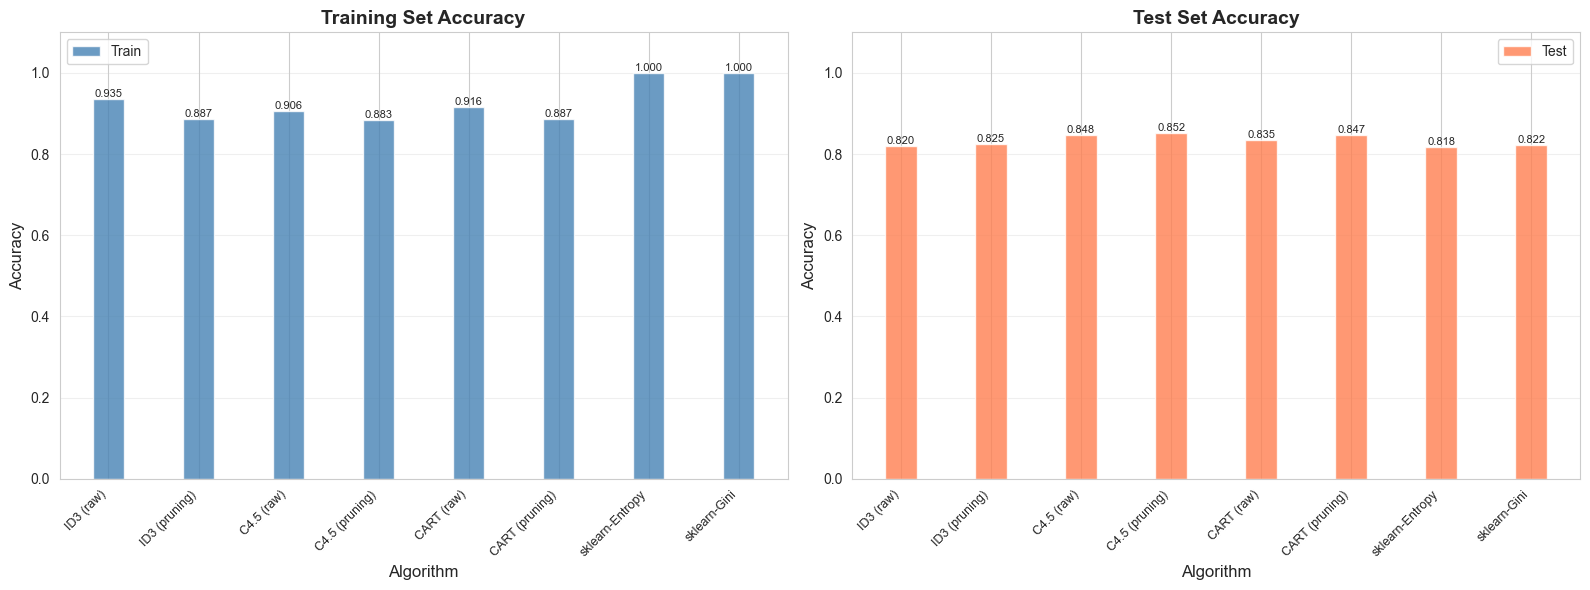

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

pic_dir = 'pic'

# 准确率对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 训练集准确率
ax1 = axes[0]
x = np.arange(len(all_results))
width = 0.35

bars1 = ax1.bar(x, all_results['train_accuracy'], width, label='Train', 
                color='steelblue', alpha=0.8)
ax1.set_xlabel('Algorithm', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Training Set Accuracy', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(all_results['algorithm'], rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0, 1.1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=8)

# 测试集准确率
ax2 = axes[1]
bars2 = ax2.bar(x, all_results['test_accuracy'], width, label='Test',
                color='coral', alpha=0.8)
ax2.set_xlabel('Algorithm', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Test Set Accuracy', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(all_results['algorithm'], rotation=45, ha='right', fontsize=9)
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print(f" 图片已保存: {pic_dir}/adult_accuracy_comparison.png")
plt.show()


✓ 图片已保存: pic/adult_train_test_comparison.png


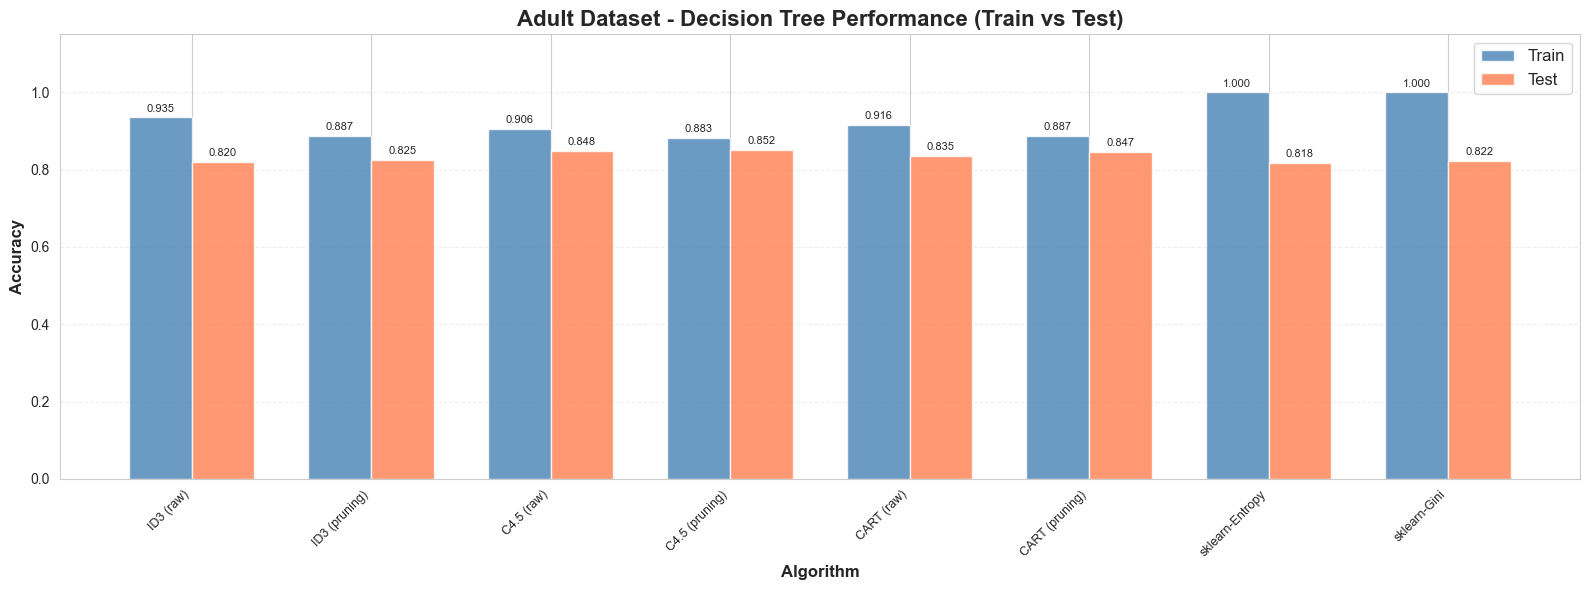

In [15]:
# 训练集vs测试集准确率对比（并排）
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(all_results))
width = 0.35

bars1 = ax.bar(x - width/2, all_results['train_accuracy'], width, 
               label='训练集', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, all_results['test_accuracy'], width,
               label='测试集', color='coral', alpha=0.8)

ax.set_xlabel('算法', fontsize=12, fontweight='bold')
ax.set_ylabel('准确率', fontsize=12, fontweight='bold')
ax.set_title('Adult数据集 - 决策树算法性能对比（训练集 vs 测试集）', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_results['algorithm'], rotation=45, ha='right', fontsize=9)
ax.set_ylim([0, 1.15])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_train_test_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/adult_train_test_comparison.png")
plt.show()


✓ 图片已保存: pic/adult_confusion_matrix.png


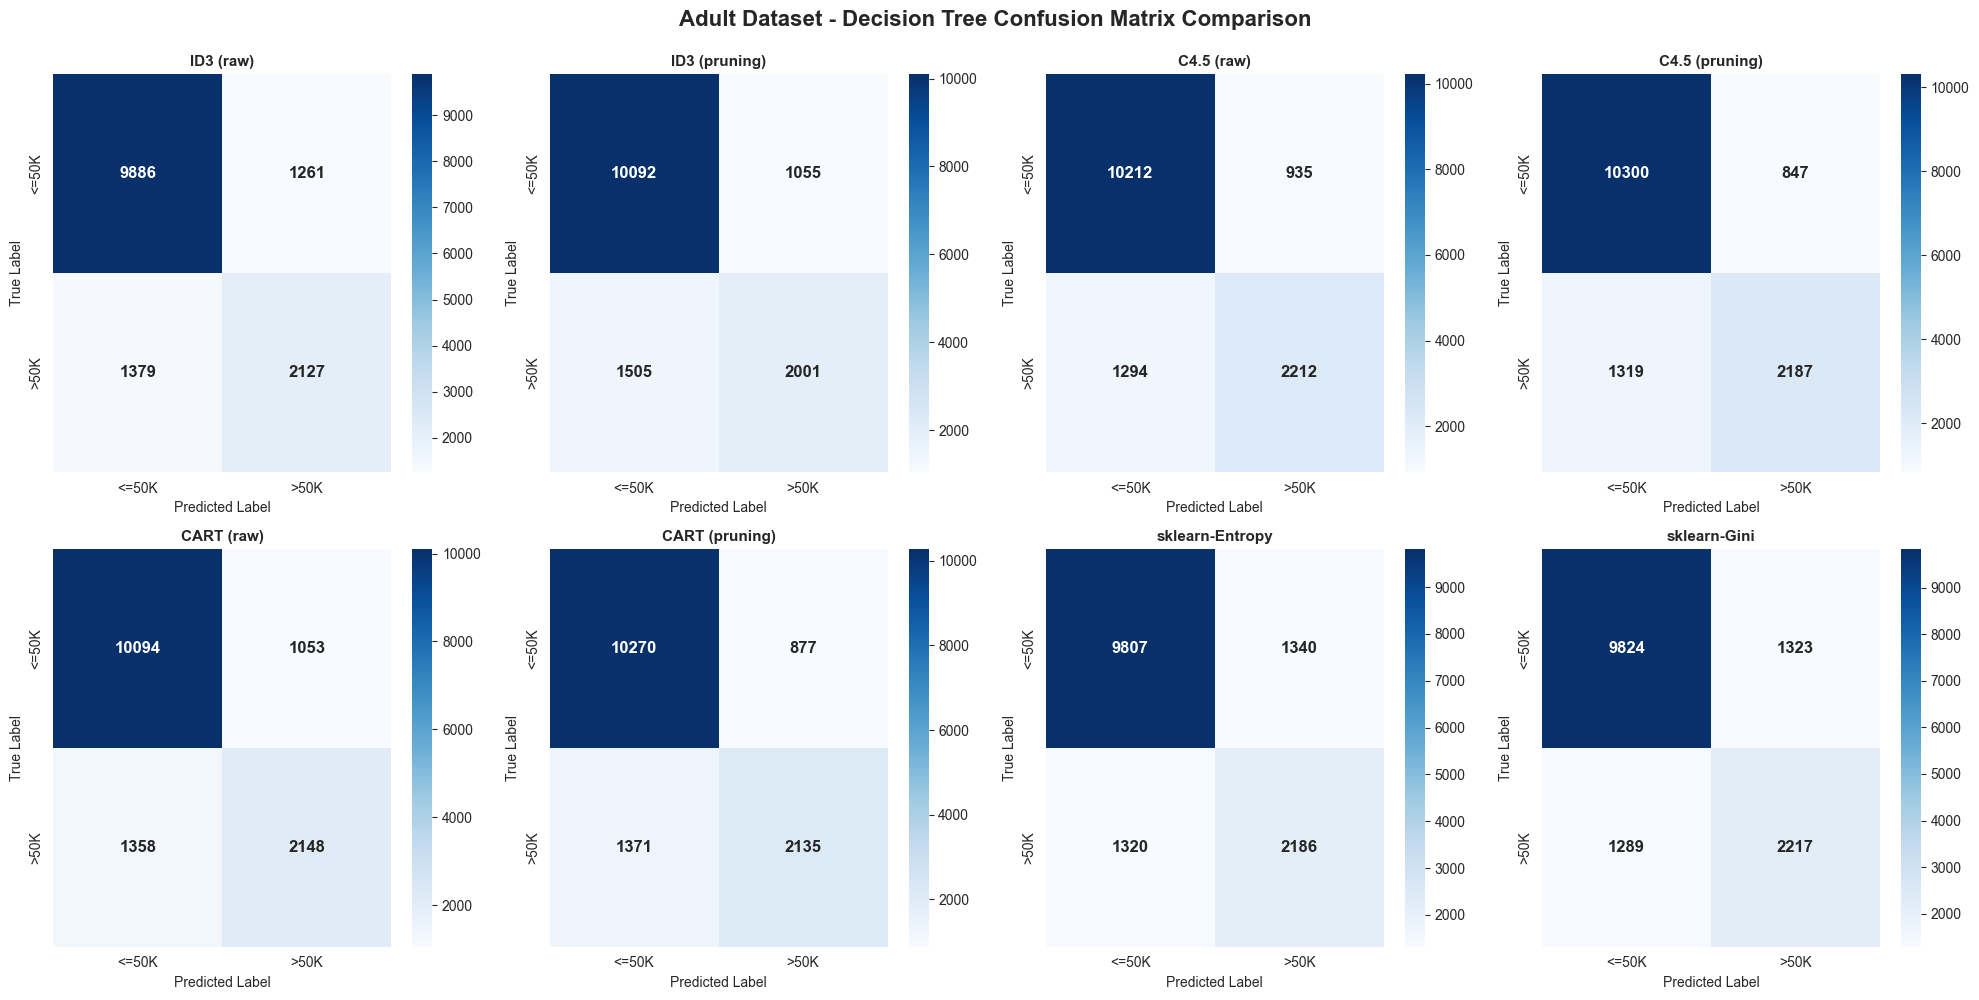

In [16]:
from sklearn.metrics import confusion_matrix

# 准备所有模型的预测结果
models_predictions = [
    ('ID3 (原始)', id3_test_pred),
    ('ID3 (剪枝)', id3_pruned_test_pred),
    ('C4.5 (原始)', c45_test_pred),
    ('C4.5 (剪枝)', c45_pruned_test_pred),
    ('CART (原始)', cart_test_pred),
    ('CART (剪枝)', cart_pruned_test_pred),
    ('sklearn-Entropy', dt_entropy_test_pred),
    ('sklearn-Gini', dt_gini_test_pred)
]

# 创建混淆矩阵图
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

labels = ['<=50K', '>50K']

for i, (name, pred) in enumerate(models_predictions):
    cm = confusion_matrix(y_test, pred, labels=labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, 
                yticklabels=labels,
                ax=axes[i], cbar=True,
                annot_kws={'size': 12, 'weight': 'bold'})
    
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('预测类别', fontsize=10)
    axes[i].set_ylabel('真实类别', fontsize=10)

plt.suptitle('Adult数据集 - 决策树算法混淆矩阵对比', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/adult_confusion_matrix.png")
plt.show()


In [18]:
# 获取各算法的特征重要性
id3_importance = id3.get_feature_importances()
id3_pruned_importance = id3_pruned.get_feature_importances()
c45_importance = c45.get_feature_importances()
c45_pruned_importance = c45_pruned.get_feature_importances()
cart_importance = cart.get_feature_importances()
cart_pruned_importance = cart_pruned.get_feature_importances()

# sklearn的特征重要性
sklearn_entropy_importance = dict(zip(X_train.columns, dt_entropy.feature_importances_))
sklearn_gini_importance = dict(zip(X_train.columns, dt_gini.feature_importances_))

print("="*60)
print("特征重要性对比")
print("="*60)

# 创建特征重要性对比表
all_features = X_train.columns.tolist()
importance_df = pd.DataFrame({
    '特征': all_features,
    'ID3 (原始)': [id3_importance.get(f, 0.0) for f in all_features],
    'ID3 (剪枝)': [id3_pruned_importance.get(f, 0.0) for f in all_features],
    'C4.5 (原始)': [c45_importance.get(f, 0.0) for f in all_features],
    'C4.5 (剪枝)': [c45_pruned_importance.get(f, 0.0) for f in all_features],
    'CART (原始)': [cart_importance.get(f, 0.0) for f in all_features],
    'CART (剪枝)': [cart_pruned_importance.get(f, 0.0) for f in all_features],
    'sklearn-Entropy': [sklearn_entropy_importance.get(f, 0.0) for f in all_features],
    'sklearn-Gini': [sklearn_gini_importance.get(f, 0.0) for f in all_features]
})

# 按重要性排序（取前10个最重要的特征）
importance_df_sorted = importance_df.sort_values(by='ID3 (原始)', ascending=False)
print("\n前10个最重要的特征（按ID3原始模型）:")
print(importance_df_sorted.head(10).to_string(index=False))


特征重要性对比

前10个最重要的特征（按ID3原始模型）:
            特征  ID3 (原始)  ID3 (剪枝)  C4.5 (原始)  C4.5 (剪枝)  CART (原始)  CART (剪枝)  sklearn-Entropy  sklearn-Gini
  relationship  0.262537  0.260585   0.011853   0.008899   0.009492   0.006027         0.000000      0.000095
        fnlwgt  0.143060  0.132554   0.089489   0.098885   0.121450   0.132142         0.000000      0.000000
    occupation  0.134876  0.133984   0.007332   0.007981   0.047854   0.044291         0.004016      0.004810
           age  0.115833  0.124945   0.108585   0.118964   0.093864   0.095897         0.004197      0.004139
  capital-gain  0.109607  0.111801   0.389392   0.386221   0.137045   0.140312         0.001094      0.000417
     education  0.056418  0.061822   0.004833   0.005129   0.012255   0.017409         0.010676      0.009184
hours-per-week  0.053935  0.055524   0.064571   0.055351   0.052091   0.048031         0.000046      0.000000
native-country  0.039526  0.037839   0.015735   0.014410   0.003739   0.004921         0.

✓ 图片已保存: pic/adult_feature_importance.png


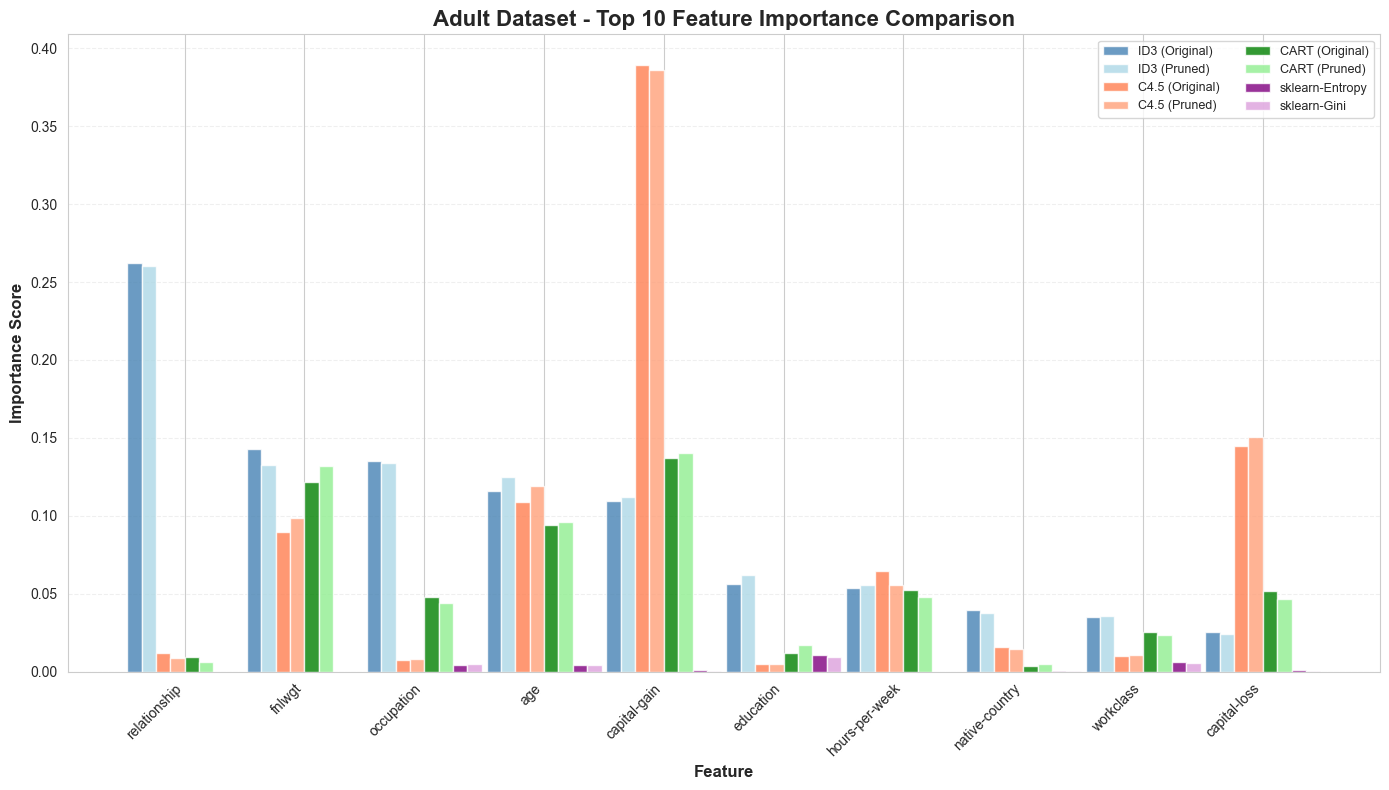

In [30]:
# 特征重要性可视化（前10个特征）
top_n = 10
top_features = importance_df_sorted.head(top_n)['特征'].tolist()
top_importance_df = importance_df_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_features))
width = 0.12

# English algorithm names for plotting
algorithms_en = ['ID3 (Original)', 'ID3 (Pruned)', 'C4.5 (Original)', 'C4.5 (Pruned)',
                 'CART (Original)', 'CART (Pruned)', 'sklearn-Entropy', 'sklearn-Gini']
algorithm_column_mapping_en = {
    'ID3 (Original)':      'ID3 (原始)',
    'ID3 (Pruned)':        'ID3 (剪枝)',
    'C4.5 (Original)':     'C4.5 (原始)',
    'C4.5 (Pruned)':       'C4.5 (剪枝)',
    'CART (Original)':     'CART (原始)',
    'CART (Pruned)':       'CART (剪枝)',
    'sklearn-Entropy':     'sklearn-Entropy',
    'sklearn-Gini':        'sklearn-Gini'
}
colors = ['steelblue', 'lightblue', 'coral', 'lightsalmon',
          'green', 'lightgreen', 'purple', 'plum']

for i, (algo_en, color) in enumerate(zip(algorithms_en, colors)):
    offset = (i - len(algorithms_en)/2) * width + width/2
    bars = ax.bar(x + offset, top_importance_df[algorithm_column_mapping_en[algo_en]], width, 
                  label=algo_en, color=color, alpha=0.8)

ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title(f'Adult Dataset - Top {top_n} Feature Importance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=45, ha='right')
ax.legend(fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/adult_feature_importance.png")
plt.show()


✓ Image saved: pic/adult_feature_importance_heatmap.png


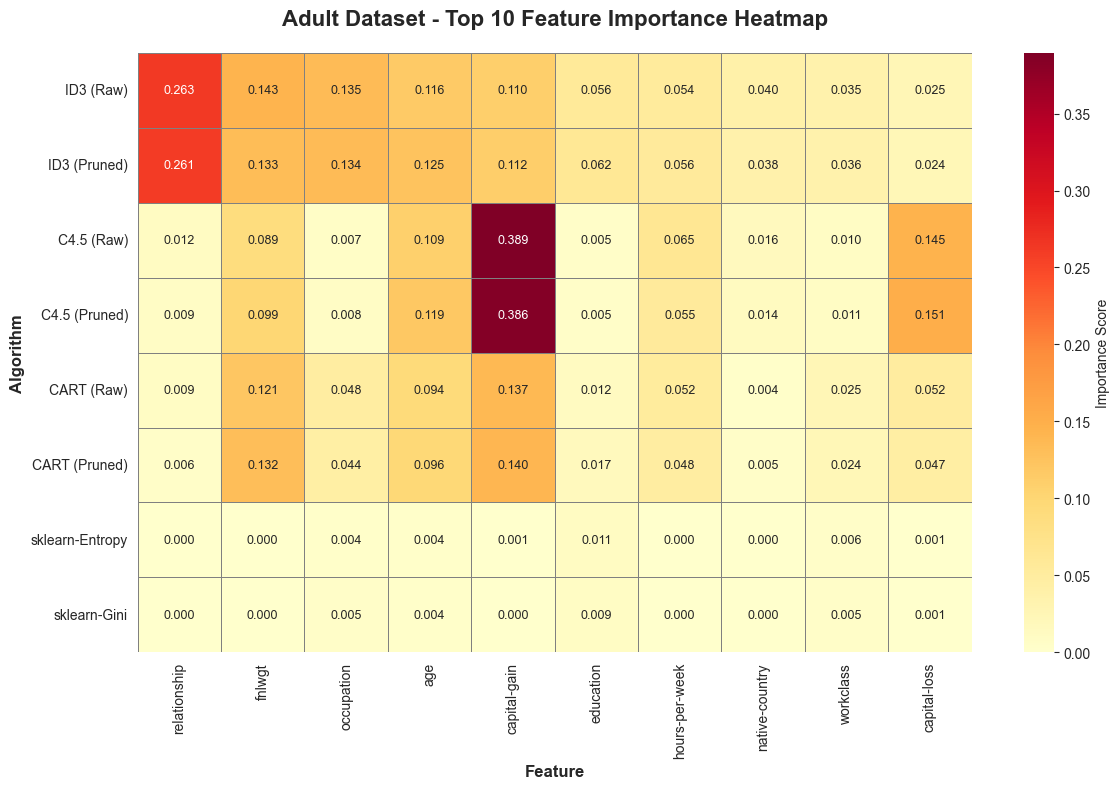

In [21]:
# 特征重要性热力图（前10个特征）
fig, ax = plt.subplots(figsize=(12, 8))

heatmap_data = top_importance_df.set_index('特征').T

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': '重要性分数'}, ax=ax, 
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 9})

ax.set_title(f'Adult数据集 - 前{top_n}个特征重要性热力图', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('特征', fontsize=12, fontweight='bold')
ax.set_ylabel('算法', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/adult_feature_importance_heatmap.png")
plt.show()


✓ 图片已保存: pic/adult_overfitting_analysis.png


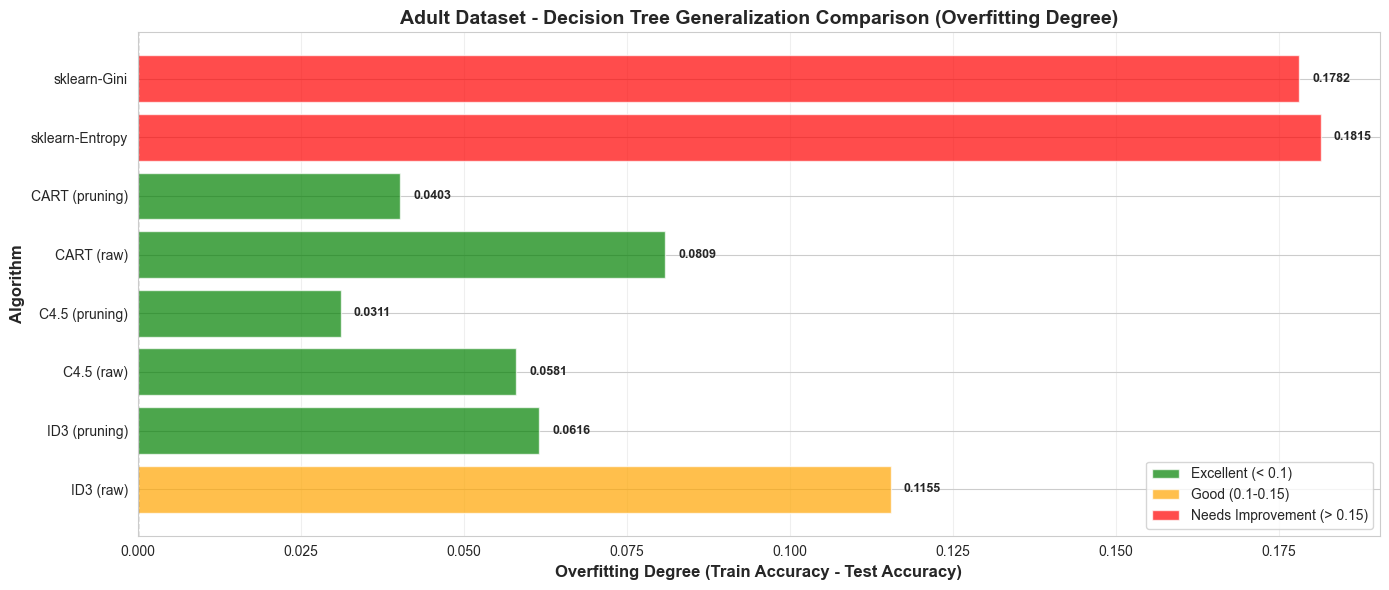

In [22]:
# 过拟合程度可视化
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['green' if x < 0.1 else 'orange' if x < 0.15 else 'red' 
          for x in all_results['overfitting']]

bars = ax.barh(all_results['algorithm'], all_results['overfitting'], 
               color=colors, alpha=0.7)
ax.set_xlabel('过拟合程度（训练集准确率 - 测试集准确率）', fontsize=12, fontweight='bold')
ax.set_ylabel('算法', fontsize=12, fontweight='bold')
ax.set_title('Adult数据集 - 决策树算法泛化能力对比（过拟合程度）', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, all_results['overfitting'])):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}',
            va='center', fontsize=9, fontweight='bold')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='优秀 (< 0.1)'),
    Patch(facecolor='orange', alpha=0.7, label='良好 (0.1-0.15)'),
    Patch(facecolor='red', alpha=0.7, label='需要改进 (> 0.15)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_overfitting_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/adult_overfitting_analysis.png")
plt.show()


In [23]:
# 剪枝前后对比
pruning_comparison = pd.DataFrame({
    '算法': ['ID3', 'C4.5', 'CART'],
    '原始-训练集准确率': [
        accuracy_score(y_train, id3_train_pred),
        accuracy_score(y_train, c45_train_pred),
        accuracy_score(y_train, cart_train_pred)
    ],
    '剪枝-训练集准确率': [
        accuracy_score(y_train, id3_pruned_train_pred),
        accuracy_score(y_train, c45_pruned_train_pred),
        accuracy_score(y_train, cart_pruned_train_pred)
    ],
    '原始-测试集准确率': [
        accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_test, cart_test_pred)
    ],
    '剪枝-测试集准确率': [
        accuracy_score(y_test, id3_pruned_test_pred),
        accuracy_score(y_test, c45_pruned_test_pred),
        accuracy_score(y_test, cart_pruned_test_pred)
    ],
    '原始-过拟合程度': [
        accuracy_score(y_train, id3_train_pred) - accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_train, c45_train_pred) - accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_train, cart_train_pred) - accuracy_score(y_test, cart_test_pred)
    ],
    '剪枝-过拟合程度': [
        accuracy_score(y_train, id3_pruned_train_pred) - accuracy_score(y_test, id3_pruned_test_pred),
        accuracy_score(y_train, c45_pruned_train_pred) - accuracy_score(y_test, c45_pruned_test_pred),
        accuracy_score(y_train, cart_pruned_train_pred) - accuracy_score(y_test, cart_pruned_test_pred)
    ],
})

# 计算改进
pruning_comparison['测试集准确率提升'] = (
    pruning_comparison['剪枝-测试集准确率'] - pruning_comparison['原始-测试集准确率']
)
pruning_comparison['过拟合减少'] = (
    pruning_comparison['原始-过拟合程度'] - pruning_comparison['剪枝-过拟合程度']
)

print("="*80)
print("后剪枝效果对比分析")
print("="*80)
print(pruning_comparison.to_string(index=False))
print("="*80)


后剪枝效果对比分析
  算法  原始-训练集准确率  剪枝-训练集准确率  原始-测试集准确率  剪枝-测试集准确率  原始-过拟合程度  剪枝-过拟合程度  测试集准确率提升    过拟合减少
 ID3   0.935359   0.886893   0.819832   0.825292  0.115527  0.061602  0.005460 0.053926
C4.5   0.905935   0.883325   0.847881   0.852180  0.058054  0.031145  0.004299 0.026909
CART   0.916347   0.886893   0.835460   0.846584  0.080887  0.040309  0.011124 0.040578


✓ 图片已保存: pic/adult_pruning_comparison.png


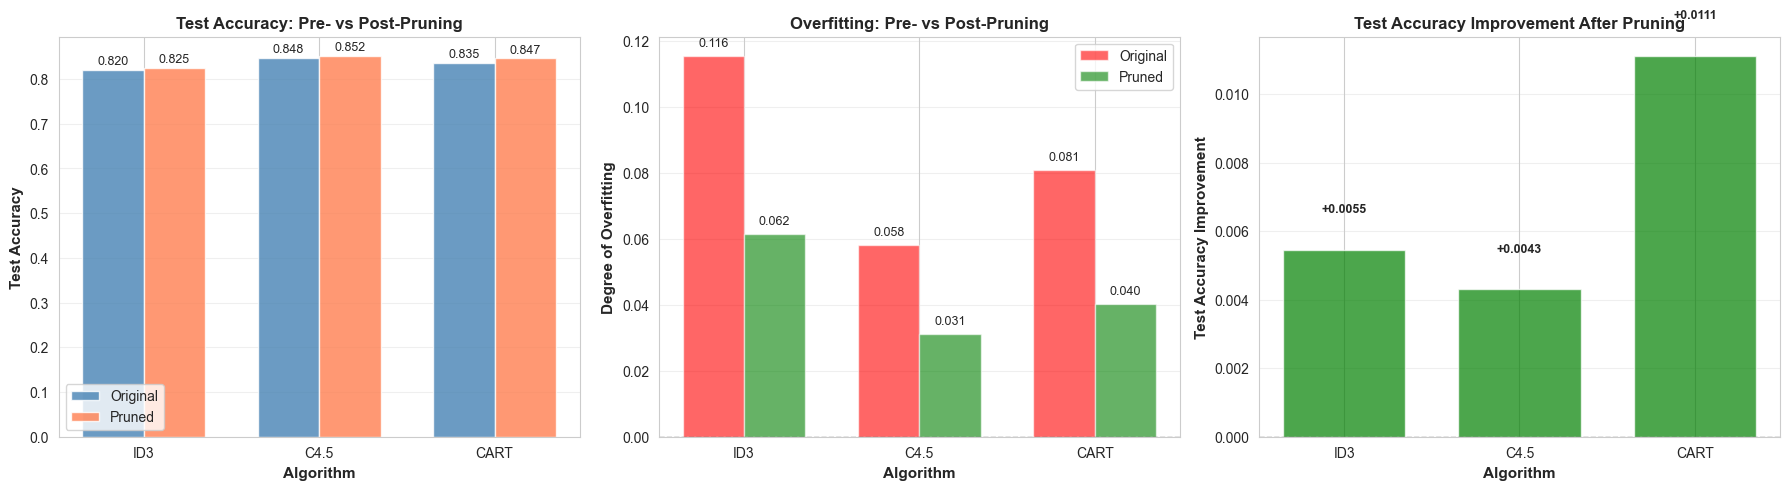

In [25]:
# 剪枝前后对比可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algorithms = pruning_comparison['算法'].tolist()
x = np.arange(len(algorithms))
width = 0.35

# 1. 测试集准确率对比
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, pruning_comparison['原始-测试集准确率'], width,
                label='Original', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, pruning_comparison['剪枝-测试集准确率'], width,
                label='Pruned', color='coral', alpha=0.8)
ax1.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Test Accuracy: Pre- vs Post-Pruning', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(algorithms)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. 过拟合程度对比
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, pruning_comparison['原始-过拟合程度'], width,
                label='Original', color='red', alpha=0.6)
bars4 = ax2.bar(x + width/2, pruning_comparison['剪枝-过拟合程度'], width,
                label='Pruned', color='green', alpha=0.6)
ax2.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax2.set_ylabel('Degree of Overfitting', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting: Pre- vs Post-Pruning', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 3. 改进幅度
ax3 = axes[2]
colors_improve = ['green' if x > 0 else 'red' for x in pruning_comparison['测试集准确率提升']]
bars5 = ax3.bar(x, pruning_comparison['测试集准确率提升'], width*2,
                color=colors_improve, alpha=0.7)
ax3.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax3.set_ylabel('Test Accuracy Improvement', fontsize=11, fontweight='bold')
ax3.set_title('Test Accuracy Improvement After Pruning', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(algorithms)
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
for bar in bars5:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + (0.001 if height >= 0 else -0.003),
             f'{height:+.4f}', ha='center', 
             va='bottom' if height >= 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{pic_dir}/adult_pruning_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/adult_pruning_comparison.png")
plt.show()


In [29]:
print("="*80)
print("实验总结")
print("="*80)

print("\n1. 算法性能排名（按测试集准确率）:")
test_ranking = all_results.nlargest(8, 'test_accuracy')[['algorithm', 'test_accuracy']]
for i, (idx, row) in enumerate(test_ranking.iterrows(), 1):
    print(f"   {i}. {row['algorithm']:20s}: {row['test_accuracy']:.6f}")

print("\n2. 泛化能力排名（按过拟合程度，越小越好）:")
overfitting_ranking = all_results.nsmallest(8, 'overfitting')[['algorithm', 'overfitting']]
for i, (idx, row) in enumerate(overfitting_ranking.iterrows(), 1):
    print(f"   {i}. {row['algorithm']:20s}: {row['overfitting']:.6f}")

print("\n3. 后剪枝效果总结:")
print(f"   - ID3: 测试集准确率 {'提升' if pruning_comparison.loc[0, '测试集准确率提升'] > 0 else '下降'} "
      f"{abs(pruning_comparison.loc[0, '测试集准确率提升']):.4f}, "
      f"过拟合减少 {pruning_comparison.loc[0, '过拟合减少']:.4f}")
print(f"   - C4.5: 测试集准确率 {'提升' if pruning_comparison.loc[1, '测试集准确率提升'] > 0 else '下降'} "
      f"{abs(pruning_comparison.loc[1, '测试集准确率提升']):.4f}, "
      f"过拟合减少 {pruning_comparison.loc[1, '过拟合减少']:.4f}")
print(f"   - CART: 测试集准确率 {'提升' if pruning_comparison.loc[2, '测试集准确率提升'] > 0 else '下降'} "
      f"{abs(pruning_comparison.loc[2, '测试集准确率提升']):.4f}, "
      f"过拟合减少 {pruning_comparison.loc[2, '过拟合减少']:.4f}")

print("\n4. 最重要的特征（前5个）:")

# 获取实际列名，兼容列名格式问题
columns = importance_df_sorted.columns
feat_col = [col for col in columns if "特征" in col][0]

# 直接使用实际列名，不做多余防护
id3_col = [col for col in columns if 'ID3' in str(col)][0]
c45_col = [col for col in columns if 'C4.5' in str(col)][0]
cart_col = [col for col in columns if 'CART' in str(col)][0]

top5_features = importance_df_sorted.head(5)
for i, (idx, row) in enumerate(top5_features.iterrows(), 1):
    id3_val = row[id3_col]
    c45_val = row[c45_col]
    cart_val = row[cart_col]
    print(f"   {i}. {row[feat_col]:20s}: ID3={id3_val:.4f}, C4.5={c45_val:.4f}, CART={cart_val:.4f}")


print("\n" + "="*80)
print("所有图片已保存到 pic/ 文件夹")
print("="*80)


实验总结

1. 算法性能排名（按测试集准确率）:
   1. C4.5 (pruning)      : 0.852180
   2. C4.5 (raw)          : 0.847881
   3. CART (pruning)      : 0.846584
   4. CART (raw)          : 0.835460
   5. ID3 (pruning)       : 0.825292
   6. sklearn-Gini        : 0.821743
   7. ID3 (raw)           : 0.819832
   8. sklearn-Entropy     : 0.818467

2. 泛化能力排名（按过拟合程度，越小越好）:
   1. C4.5 (pruning)      : 0.031145
   2. CART (pruning)      : 0.040309
   3. C4.5 (raw)          : 0.058054
   4. ID3 (pruning)       : 0.061602
   5. CART (raw)          : 0.080887
   6. ID3 (raw)           : 0.115527
   7. sklearn-Gini        : 0.178199
   8. sklearn-Entropy     : 0.181474

3. 后剪枝效果总结:
   - ID3: 测试集准确率 提升 0.0055, 过拟合减少 0.0539
   - C4.5: 测试集准确率 提升 0.0043, 过拟合减少 0.0269
   - CART: 测试集准确率 提升 0.0111, 过拟合减少 0.0406

4. 最重要的特征（前5个）:
   1. relationship        : ID3=0.2625, C4.5=0.0119, CART=0.0095
   2. fnlwgt              : ID3=0.1431, C4.5=0.0895, CART=0.1215
   3. occupation          : ID3=0.1349, C4.5=0.0073, CART=0.0479
   4. a